# MVDS with Null Values — Five Handling Strategies
## How missing data affects the Multivariate Variogram Dispersion Score

| Strategy | Bias risk | Cost | When to use |
|----------|----------|------|-------------|
| **1. Pairwise omission** | Low (MCAR) / High (clustered) | Negligible | First pass |
| **2. Indicator variogram** | N/A (diagnostic) | Low | Always run first |
| **3. Declustering weights** | Low | Low | Clustered valid data |
| **4. SGS imputation ensemble** | Very low | High | Final analysis |
| **5. EM variogram fitting** | Very low | Medium | Moderate null fraction |

Three null scenarios are applied to both areas:
- **S1** — Random nulls (15%, MCAR)
- **S2** — Clustered nulls (fault corridor + lease boundary)
- **S3** — Systematic edge fade (structurally correlated)

## 0. Setup, grid generation & null mask creation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import gaussian_filter
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

GRID   = 80
AREAS  = ['Area A', 'Area B']
PROPS  = ['Structure', 'Porosity', 'Isopach', 'Sw', 'GR']
COLORS = {'Area A': '#185FA5', 'Area B': '#993C1D'}
GEO_WEIGHTS = {'Structure': 0.10, 'Porosity': 0.30,
               'Isopach':   0.20, 'Sw':       0.25, 'GR': 0.15}
np.random.seed(42)
print('Setup complete')

Setup complete


In [2]:
def bf_A(nx, ny):
    return (0.42*np.sin(nx*np.pi*1.2+0.3)*np.cos(ny*np.pi*0.9+0.5)
           +0.28*np.sin(nx*np.pi*2.1+1.1)*np.sin(ny*np.pi*1.7+0.8)
           +0.18*np.cos(nx*np.pi*3.0+0.7)*np.cos(ny*np.pi*2.5+1.3)
           +0.08*np.sin(nx*np.pi*4.0+2.0)*np.cos(ny*np.pi*3.8+0.4)
           +0.14*(1-np.exp(-((nx-0.30)**2+(ny-0.25)**2)/0.015))
           -0.11*np.exp(-((nx-0.72)**2+(ny-0.68)**2)/0.012))

def bf_B(nx, ny):
    return (0.35*np.sin(nx*np.pi*2.5+0.8)*np.cos(ny*np.pi*1.8+1.2)
           +0.22*np.cos(nx*np.pi*4.2+0.4)*np.sin(ny*np.pi*3.1+0.7)
           +0.28*np.sin(nx*np.pi*1.1+1.5)*np.cos(ny*np.pi*2.4+0.3)
           +0.15*np.cos(nx*np.pi*5.5+2.1)*np.cos(ny*np.pi*4.0+1.8)
           +0.18*np.exp(-((nx-0.55)**2+(ny-0.40)**2)/0.018)
           -0.14*np.exp(-((nx-0.22)**2+(ny-0.75)**2)/0.010)
           -0.10*np.exp(-((nx-0.78)**2+(ny-0.20)**2)/0.013))

x = np.linspace(0, 1, GRID+1)
NX, NY = np.meshgrid(x, x)
BFA, BFB = bf_A(NX, NY), bf_B(NX, NY)
C = np.clip

grids = {
    'Area A': {
        'Structure': C(7500+900*np.sin(NX*np.pi*1.2+0.3)*np.cos(NY*np.pi*0.9+0.5)
                       +600*np.sin(NX*np.pi*2.1+1.1)*np.sin(NY*np.pi*1.7+0.8)
                       +400*np.cos(NX*np.pi*3.0+0.7)*np.cos(NY*np.pi*2.5+1.3)
                       +200*np.sin(NX*np.pi*4.0+2.0)*np.cos(NY*np.pi*3.8+0.4)
                       +300*(1-np.exp(-((NX-0.30)**2+(NY-0.25)**2)/0.015))
                       -250*np.exp(-((NX-0.72)**2+(NY-0.68)**2)/0.012), 7500, 10000),
        'Porosity': C(0.075+0.025*BFA, 0.05, 0.10),
        'Isopach':  C(40+20*(-BFA*0.9+0.05*np.sin(NX*5)*np.cos(NY*4)), 20, 60),
        'Sw':       C(0.40-0.18*BFA+0.04*np.cos(NX*6+NY*4), 0.20, 0.60),
        'GR':       C(75+42*(BFA*0.8+0.12*np.sin(NX*7+1)*np.sin(NY*5+0.5)), 30, 120),
    },
    'Area B': {
        'Structure': C(8800+600*np.sin(NX*np.pi*2.5+0.8)*np.cos(NY*np.pi*1.8+1.2)
                       +400*np.cos(NX*np.pi*4.2+0.4)*np.sin(NY*np.pi*3.1+0.7)
                       +300*np.exp(-((NX-0.55)**2+(NY-0.40)**2)/0.018)
                       -200*np.exp(-((NX-0.22)**2+(NY-0.75)**2)/0.010), 7800, 9800),
        'Porosity': C(0.10+0.04*BFB+0.008*np.cos(NX*8)*np.sin(NY*6), 0.06, 0.14),
        'Isopach':  C(40+18*(BFB*0.7+0.15*np.sin(NX*9+1)*np.cos(NY*7+2)), 20, 60),
        'Sw':       C(0.35-0.16*BFB+0.06*np.sin(NX*7+NY*5+0.5)+0.03*np.cos(NX*11), 0.15, 0.55),
        'GR':       C(78+48*(BFB*0.6+0.20*np.sin(NX*10+2)*np.cos(NY*8+1)+0.08*np.sin(NX*15)), 25, 130),
    }
}
print('Grids ready')

Grids ready


S1 (Random 15%): 15.0% null
S2 (Clustered fault+lease): 11.3% null
S3 (Systematic edge fade): 17.5% null


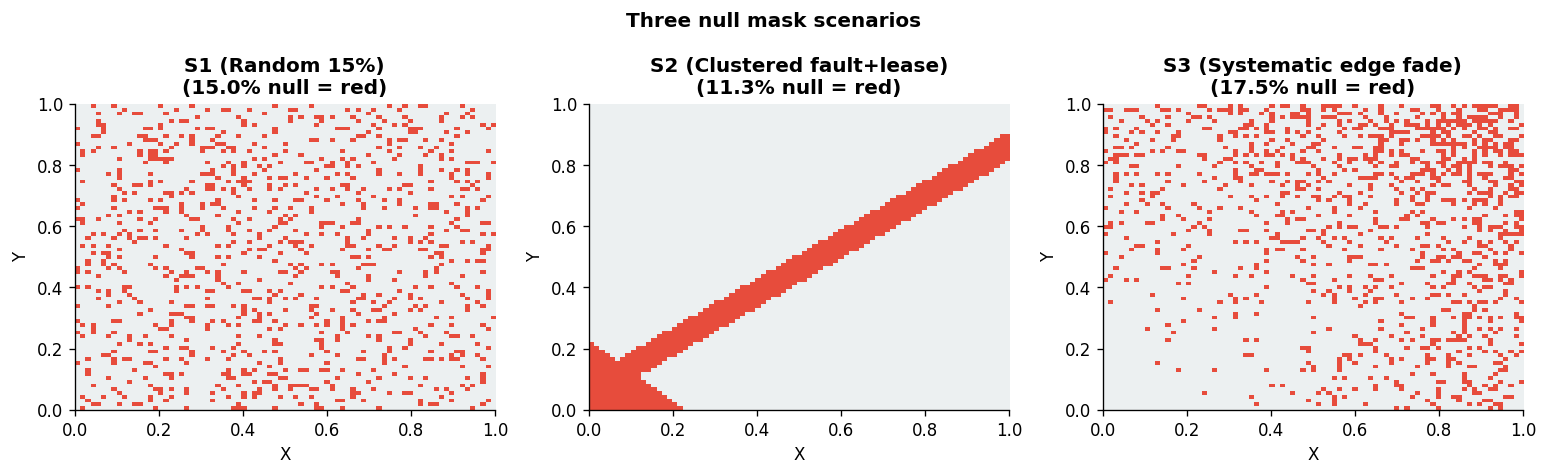

In [3]:
rng = np.random.default_rng(0)
rows, cols = GRID+1, GRID+1
N = rows * cols

# S1: Random MCAR 15%
mask_S1 = np.ones(N, dtype=bool)
null_idx = rng.choice(N, size=int(0.15*N), replace=False)
mask_S1[null_idx] = False
mask_S1 = mask_S1.reshape(rows, cols)

# S2: Clustered — diagonal fault + NW corner lease
mask_S2 = np.ones((rows, cols), dtype=bool)
r_idx, c_idx = np.mgrid[0:rows, 0:cols]
fault_dist = np.abs(r_idx - c_idx*0.8 - 5)
mask_S2[fault_dist < 4] = False
mask_S2[(r_idx < 18) & (c_idx < 18-r_idx)] = False

# S3: Systematic edge fade toward SE corner
prob_null = np.clip(((r_idx/rows)**2 + (c_idx/cols)**2) / 4.0, 0, 0.70)
mask_S3 = rng.random((rows, cols)) > prob_null

null_masks = {'S1 (Random 15%)': mask_S1,
              'S2 (Clustered fault+lease)': mask_S2,
              'S3 (Systematic edge fade)': mask_S3}

for name, m in null_masks.items():
    print(f'{name}: {(1-m.mean())*100:.1f}% null')

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
cmap_null = ListedColormap(['#e74c3c', '#ecf0f1'])
for ax, (name, mask) in zip(axes, null_masks.items()):
    ax.imshow(mask, origin='lower', cmap=cmap_null,
              vmin=0, vmax=1, extent=[0,1,0,1], aspect='auto')
    ax.set_title(name + '\n(' + f'{(1-mask.mean())*100:.1f}% null = red)',
                 fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.suptitle('Three null mask scenarios', fontweight='bold')
plt.tight_layout()
# plt.savefig('00_null_masks.png', dpi=130, bbox_inches='tight')
plt.show()

## Core variogram utilities

In [4]:
def spherical(h, nugget, sill, rang):
    h = np.asarray(h, float)
    return np.where(h <= rang,
                    nugget + (sill-nugget)*(1.5*(h/rang) - 0.5*(h/rang)**3),
                    sill)

def fit_variogram(h, gamma, p0=None):
    if h is None or gamma is None:
        return None, np.nan, None
    valid = ~np.isnan(gamma) & (gamma > 0)
    if valid.sum() < 4:
        return None, np.nan, None
    hv, gv = h[valid], gamma[valid]
    if p0 is None:
        p0 = [gv.min()*0.05, gv.max(), hv.max()*0.5]
    try:
        popt, _ = curve_fit(spherical, hv, gv, p0=p0, maxfev=12000,
                            bounds=([0, 0, 0.5], [np.inf, np.inf, np.inf]))
        h_fine  = np.linspace(0, hv.max(), 500)
        g_fit   = spherical(h_fine, *popt)
        integral = np.trapezoid(g_fit / (popt[1]+1e-12), h_fine)
        return popt, integral, h_fine
    except Exception:
        return None, np.nan, None

def mvds_from_integrals(d):
    vals = [v for v in d.values() if not np.isnan(v)]
    return float(np.mean(vals)) if vals else np.nan

def sample_pairs(flat_vals, mask_flat, n_lags=18, max_lag_frac=0.45,
                 n_sample=2000, seed=0, weights=None):
    rng_  = np.random.default_rng(seed)
    valid = np.where(mask_flat)[0]
    if len(valid) < 10:
        return None, None
    idx   = rng_.choice(valid, size=min(n_sample, len(valid)), replace=False)
    ri, ci = np.unravel_index(idx, (GRID+1, GRID+1))
    coords = np.stack([ri, ci], axis=1).astype(float)
    vals   = flat_vals[idx]
    w_node = weights[idx] if weights is not None else np.ones(len(idx))
    dists  = squareform(pdist(coords))
    max_d  = dists.max() * max_lag_frac
    lags   = np.linspace(0, max_d, n_lags+1)
    gamma  = []
    for lo, hi in zip(lags[:-1], lags[1:]):
        mask = (dists > lo) & (dists <= hi)
        if mask.sum() < 5:
            gamma.append(np.nan); continue
        ii, jj = np.where(mask)
        w_pair = w_node[ii] * w_node[jj]
        w_sum  = w_pair.sum()
        if w_sum < 1e-12:
            gamma.append(np.nan); continue
        gamma.append(0.5 * np.sum(w_pair*(vals[ii]-vals[jj])**2) / w_sum)
    centers = (lags[:-1]+lags[1:])/2
    return centers, np.array(gamma)

print('Variogram utilities ready')

Variogram utilities ready


In [5]:
baseline_mvds = {}
for area in AREAS:
    integrals = {}
    for prop in PROPS:
        flat = grids[area][prop].ravel()
        h, gamma = sample_pairs(flat, np.ones(len(flat), dtype=bool))
        _, integral, _ = fit_variogram(h, gamma)
        integrals[prop] = integral
    baseline_mvds[area] = mvds_from_integrals(integrals)
    print(f'Baseline MVDS (no nulls) | {area}: {baseline_mvds[area]:.4f}')

Baseline MVDS (no nulls) | Area A: 30.5284
Baseline MVDS (no nulls) | Area B: 36.3354


---
## Strategy 1 — Pairwise omission

Skip any pair where either endpoint is null.
Unbiased when nulls are MCAR; biased when nulls are spatially clustered.

gamma(h) = 0.5 * mean[(Z(si) - Z(sj))^2]  over all valid pairs in lag class h

In [6]:
s1 = {}
for area in AREAS:
    s1[area] = {}
    for sc_name, mask in null_masks.items():
        integrals = {}
        for prop in PROPS:
            h, g = sample_pairs(grids[area][prop].ravel(), mask.ravel())
            _, integral, _ = fit_variogram(h, g)
            integrals[prop] = integral
        s1[area][sc_name] = mvds_from_integrals(integrals)
        print(f'S1 | {area} | {sc_name}: MVDS={s1[area][sc_name]:.4f}')

S1 | Area A | S1 (Random 15%): MVDS=27.8370
S1 | Area A | S2 (Clustered fault+lease): MVDS=30.4184
S1 | Area A | S3 (Systematic edge fade): MVDS=31.1907
S1 | Area B | S1 (Random 15%): MVDS=36.6645
S1 | Area B | S2 (Clustered fault+lease): MVDS=34.9485
S1 | Area B | S3 (Systematic edge fade): MVDS=36.9285


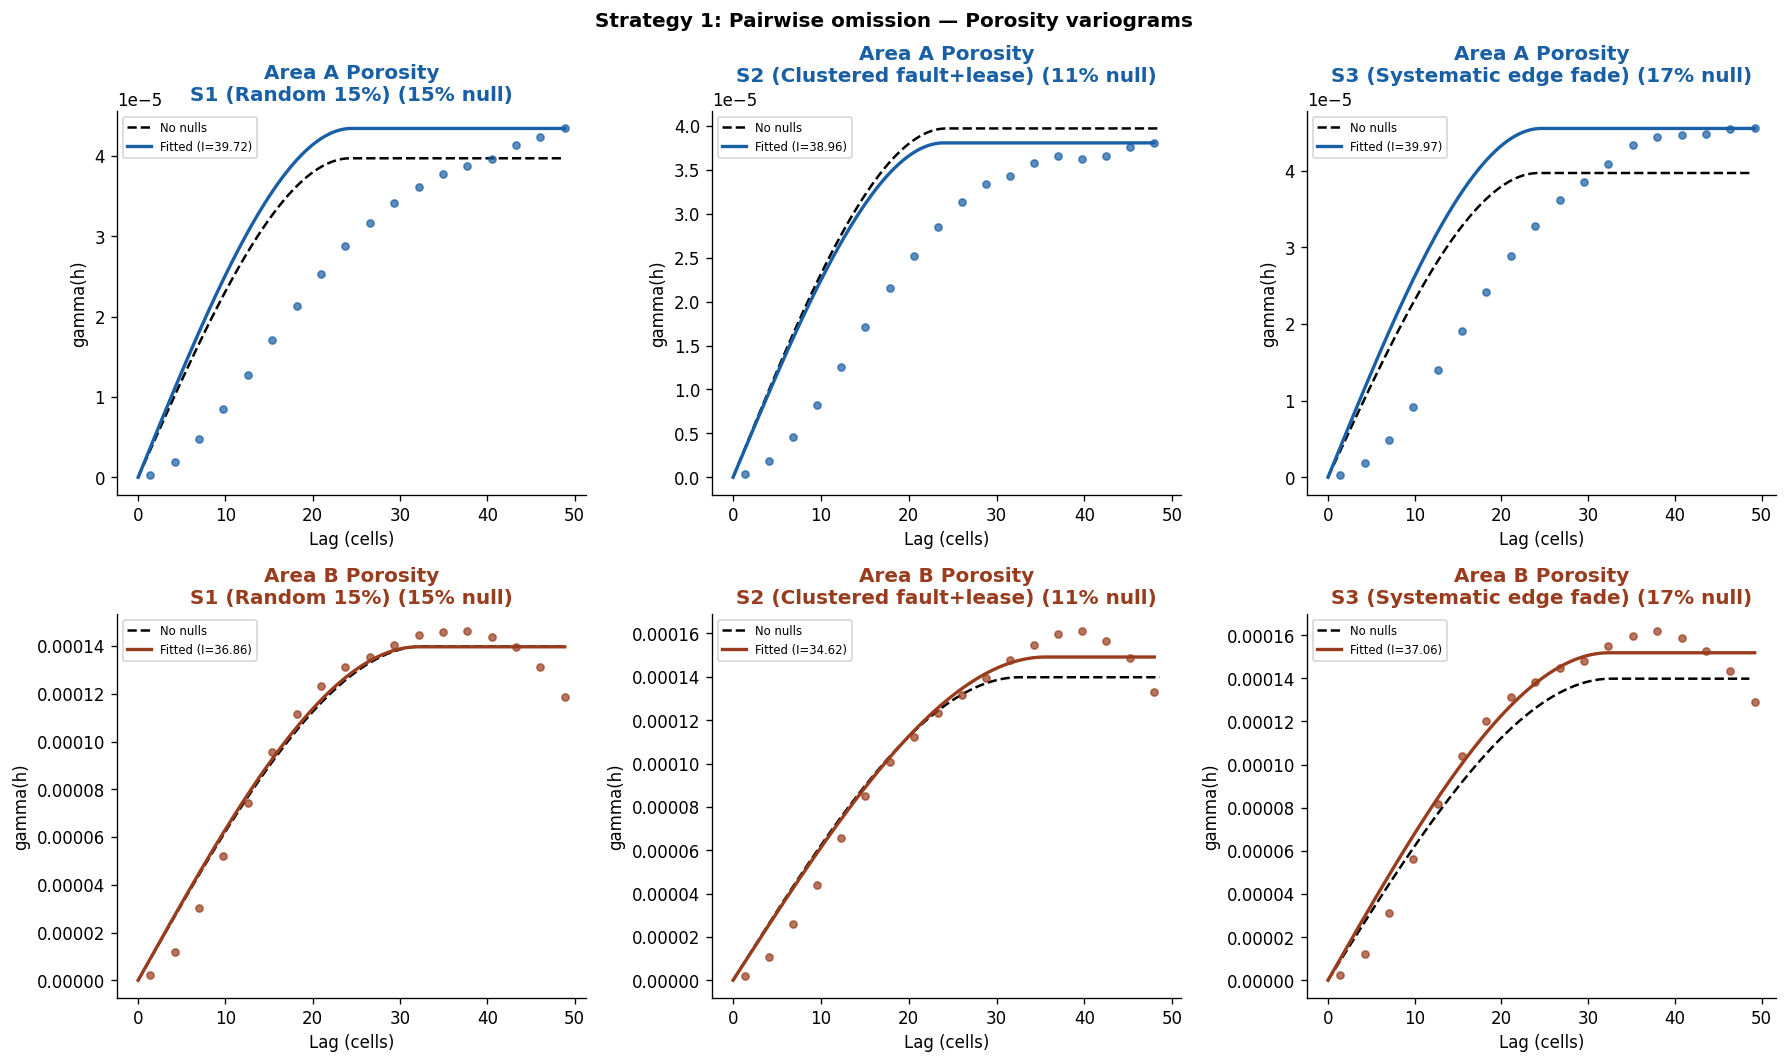

In [7]:
# Variogram curves per scenario — Porosity
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, area in enumerate(AREAS):
    for col, (sc_name, mask) in enumerate(null_masks.items()):
        ax = axes[row, col]
        flat = grids[area]['Porosity'].ravel()
        # Reference (no nulls)
        h_ref, g_ref = sample_pairs(flat, np.ones(len(flat), dtype=bool))
        p_ref, _, hf = fit_variogram(h_ref, g_ref)
        if p_ref is not None:
            ax.plot(hf, spherical(hf, *p_ref), 'k--', lw=1.5, label='No nulls')
        # With nulls
        h, g = sample_pairs(flat, mask.ravel())
        if h is not None:
            v = ~np.isnan(g)
            ax.scatter(h[v], g[v], s=18, color=COLORS[area], alpha=0.7, zorder=3)
            p, integ, hf2 = fit_variogram(h, g)
            if p is not None:
                ax.plot(hf2, spherical(hf2, *p), '-', color=COLORS[area],
                        lw=2, label=f'Fitted (I={integ:.2f})')
        pct = (1-mask.mean())*100
        ax.set_title(area + ' Porosity\n' + sc_name + f' ({pct:.0f}% null)',
                     fontweight='bold', color=COLORS[area])
        ax.set_xlabel('Lag (cells)'); ax.set_ylabel('gamma(h)')
        ax.legend(fontsize=7)
plt.suptitle('Strategy 1: Pairwise omission — Porosity variograms', fontweight='bold')
plt.tight_layout()
# plt.savefig('s1_pairwise.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Strategy 2 — Indicator variogram diagnostic

Compute the variogram of the null indicator I(s) = 1 if valid, 0 if null.

- **Flat (nugget dominant)** -> nulls are MCAR -> pairwise omission is safe
- **Structured (short range)** -> nulls are clustered -> use Strategy 3/4/5

Key metric: **Nugget/Sill ratio** — higher is safer (closer to MCAR).

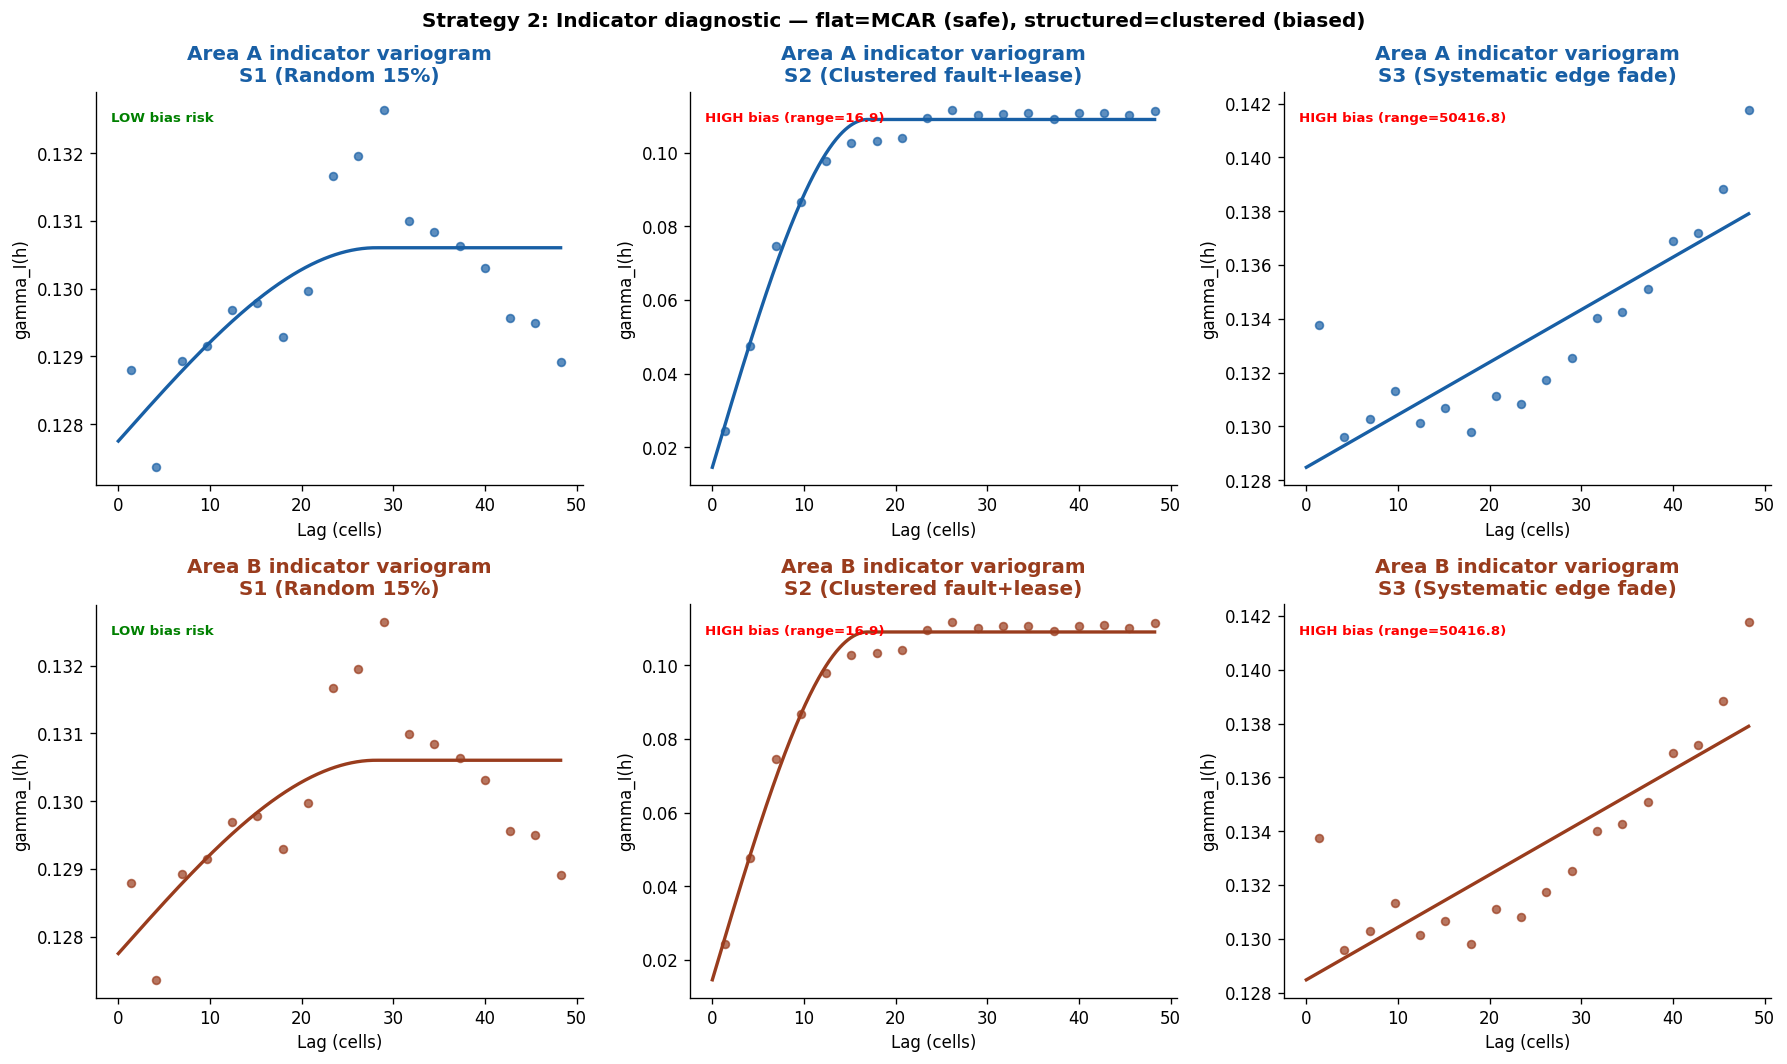

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
indic_results = {}
for row, area in enumerate(AREAS):
    indic_results[area] = {}
    for col, (sc_name, mask) in enumerate(null_masks.items()):
        ax = axes[row, col]
        indicator = mask.ravel().astype(float)
        h, g = sample_pairs(indicator, np.ones(len(indicator), dtype=bool), seed=1)
        if h is not None:
            v = ~np.isnan(g)
            ax.scatter(h[v], g[v], s=22, color=COLORS[area], alpha=0.7, zorder=3)
            popt, _, hf = fit_variogram(h, g)
            if popt is not None:
                ax.plot(hf, spherical(hf, *popt), '-', color=COLORS[area], lw=2)
                nr = popt[0]/(popt[1]+1e-12)
                indic_results[area][sc_name] = dict(
                    nugget=popt[0], sill=popt[1], range=popt[2], nugget_ratio=nr)
                risk = 'LOW bias risk' if nr > 0.6 else f'HIGH bias (range={popt[2]:.1f})'
                color_r = 'green' if nr > 0.6 else 'red'
                ax.text(0.03, 0.95, risk, transform=ax.transAxes,
                        va='top', fontsize=8, color=color_r, fontweight='bold')
        ax.set_title(area + ' indicator variogram\n' + sc_name,
                     fontweight='bold', color=COLORS[area])
        ax.set_xlabel('Lag (cells)'); ax.set_ylabel('gamma_I(h)')
plt.suptitle('Strategy 2: Indicator diagnostic — flat=MCAR (safe), structured=clustered (biased)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('s2_indicator.png', dpi=130, bbox_inches='tight')
plt.show()

In [9]:
rows_t = []
for area in AREAS:
    for sc_name, r in indic_results.get(area, {}).items():
        rows_t.append({'Area': area, 'Scenario': sc_name,
                       'Nugget': round(r['nugget'],4),
                       'Sill': round(r['sill'],4),
                       'Range': round(r['range'],1),
                       'Nugget/Sill': round(r['nugget_ratio'],3),
                       'Bias risk': 'Low' if r['nugget_ratio']>0.6 else 'HIGH'})
diag_df = pd.DataFrame(rows_t).set_index(['Area','Scenario'])
print('Indicator variogram diagnostic:')
print(diag_df.to_string())
print()
print('Rule: Nugget/Sill > 0.6 -> near-MCAR -> pairwise omission is safe')
print('      Nugget/Sill < 0.4 -> clustered nulls -> use Strategy 3/4/5')

Indicator variogram diagnostic:
                                   Nugget    Sill    Range  Nugget/Sill Bias risk
Area   Scenario                                                                  
Area A S1 (Random 15%)             0.1278  0.1306     28.1        0.978       Low
       S2 (Clustered fault+lease)  0.0146  0.1090     16.9        0.134      HIGH
       S3 (Systematic edge fade)   0.1285  6.6916  50416.8        0.019      HIGH
Area B S1 (Random 15%)             0.1278  0.1306     28.1        0.978       Low
       S2 (Clustered fault+lease)  0.0146  0.1090     16.9        0.134      HIGH
       S3 (Systematic edge fade)   0.1285  6.6916  50416.8        0.019      HIGH

Rule: Nugget/Sill > 0.6 -> near-MCAR -> pairwise omission is safe
      Nugget/Sill < 0.4 -> clustered nulls -> use Strategy 3/4/5


---
## Strategy 3 — Declustering weights

Assign each valid node weight w(s) = 1 / n_valid(s, r) where n_valid is the count
of valid neighbours within radius r. Isolated valid nodes get high weight;
clustered nodes get low weight. Applied to the weighted semivariance:

gamma_w(h) = sum_pairs[w_i * w_j * (Z_i - Z_j)^2] / (2 * sum_pairs[w_i * w_j])

In [10]:
from scipy.spatial import KDTree

def compute_decluster_weights(mask, radius_cells=8):
    rows, cols = mask.shape
    r_idx, c_idx = np.mgrid[0:rows, 0:cols]
    coords_all  = np.stack([r_idx.ravel(), c_idx.ravel()], axis=1).astype(float)
    valid_flat  = mask.ravel()
    valid_coords = coords_all[valid_flat]
    tree   = KDTree(valid_coords)
    counts = tree.query_ball_point(valid_coords, r=radius_cells, return_length=True)
    counts = np.maximum(counts, 1)
    weights = 1.0 / counts
    weights /= weights.mean()
    w_full = np.zeros(len(valid_flat))
    w_full[valid_flat] = weights
    return w_full

s3 = {}
for area in AREAS:
    s3[area] = {}
    for sc_name, mask in null_masks.items():
        w = compute_decluster_weights(mask, radius_cells=8)
        integrals = {}
        for prop in PROPS:
            h, g = sample_pairs(grids[area][prop].ravel(), mask.ravel(), weights=w)
            _, integral, _ = fit_variogram(h, g)
            integrals[prop] = integral
        s3[area][sc_name] = mvds_from_integrals(integrals)
        print(f'S3 | {area} | {sc_name}: MVDS={s3[area][sc_name]:.4f}')

S3 | Area A | S1 (Random 15%): MVDS=29.2566
S3 | Area A | S2 (Clustered fault+lease): MVDS=30.0359
S3 | Area A | S3 (Systematic edge fade): MVDS=31.9982
S3 | Area B | S1 (Random 15%): MVDS=36.5986
S3 | Area B | S2 (Clustered fault+lease): MVDS=34.7535
S3 | Area B | S3 (Systematic edge fade): MVDS=36.9421


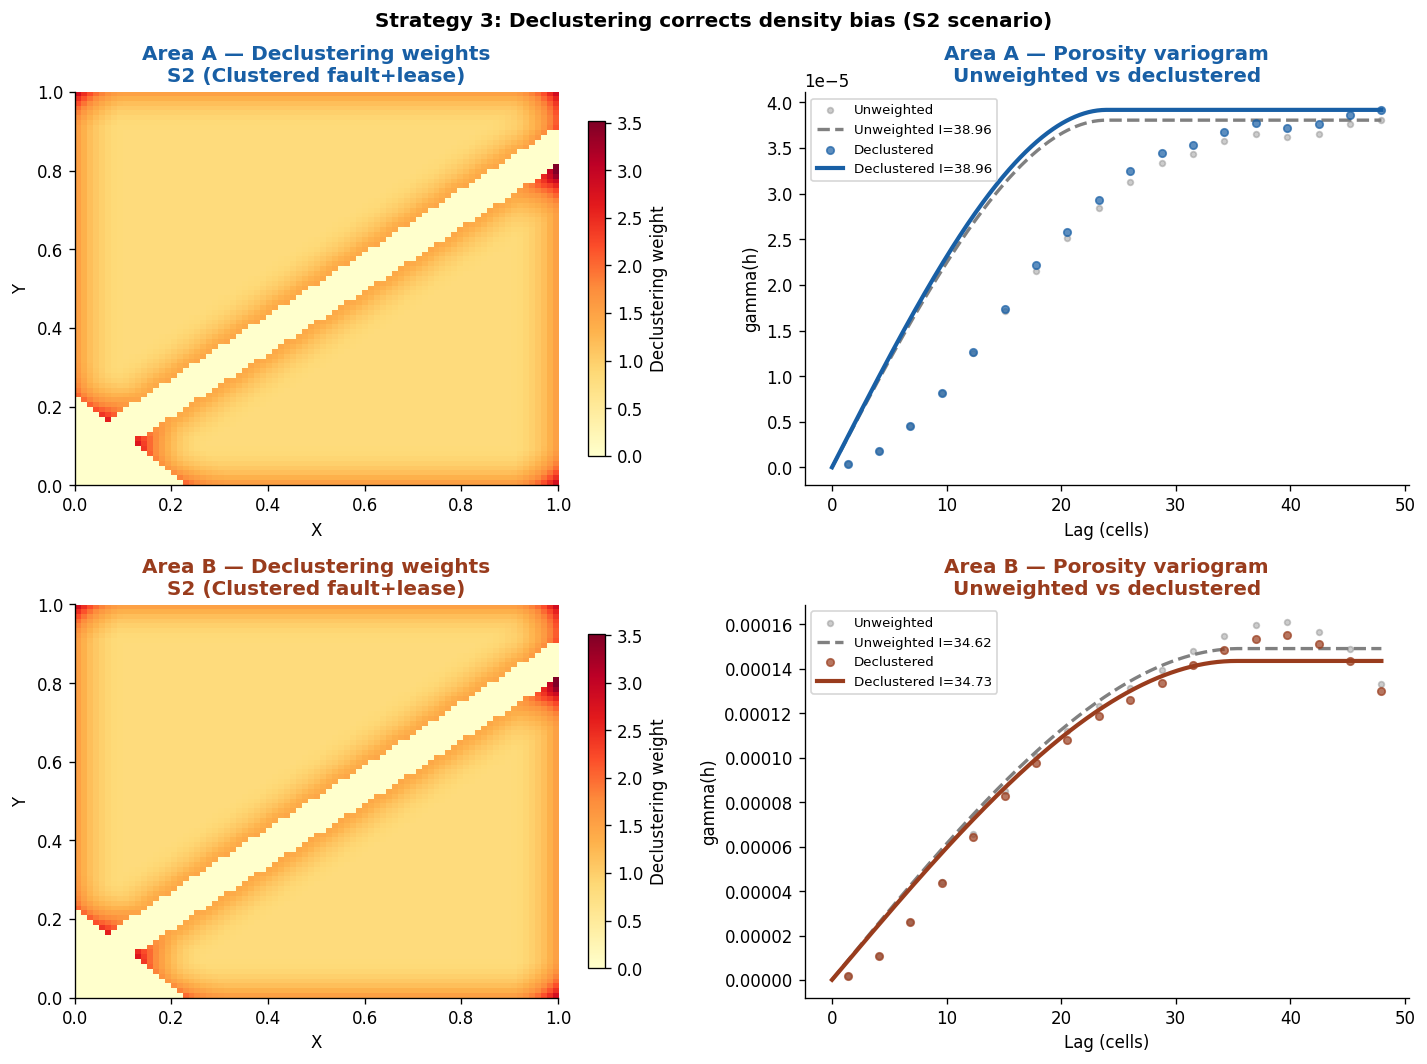

In [11]:
# Declustering weight maps + variogram comparison for S2
sc_focus = 'S2 (Clustered fault+lease)'
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, area in enumerate(AREAS):
    mask = null_masks[sc_focus]
    w = compute_decluster_weights(mask, radius_cells=8)
    # Weight map
    ax_w = axes[row, 0]
    im = ax_w.imshow(w.reshape(GRID+1, GRID+1), origin='lower', cmap='YlOrRd',
                     extent=[0,1,0,1], aspect='auto')
    plt.colorbar(im, ax=ax_w, shrink=0.85, label='Declustering weight')
    ax_w.set_title(area + ' — Declustering weights\n' + sc_focus,
                   fontweight='bold', color=COLORS[area])
    ax_w.set_xlabel('X'); ax_w.set_ylabel('Y')
    # Variogram comparison
    ax_v = axes[row, 1]
    flat = grids[area]['Porosity'].ravel()
    h_uw, g_uw = sample_pairs(flat, mask.ravel())
    if h_uw is not None:
        v = ~np.isnan(g_uw)
        ax_v.scatter(h_uw[v], g_uw[v], s=12, color='gray', alpha=0.4, label='Unweighted')
        p_uw, i_uw, hf = fit_variogram(h_uw, g_uw)
        if p_uw is not None:
            ax_v.plot(hf, spherical(hf, *p_uw), '--', color='gray', lw=2,
                      label='Unweighted I=' + f'{i_uw:.2f}')
    h_dc, g_dc = sample_pairs(flat, mask.ravel(), weights=w)
    if h_dc is not None:
        v2 = ~np.isnan(g_dc)
        ax_v.scatter(h_dc[v2], g_dc[v2], s=20, color=COLORS[area],
                     alpha=0.7, zorder=3, label='Declustered')
        p_dc, i_dc, hf2 = fit_variogram(h_dc, g_dc)
        if p_dc is not None:
            ax_v.plot(hf2, spherical(hf2, *p_dc), '-', color=COLORS[area], lw=2.5,
                      label='Declustered I=' + f'{i_dc:.2f}')
    ax_v.set_title(area + ' — Porosity variogram\nUnweighted vs declustered',
                   fontweight='bold', color=COLORS[area])
    ax_v.set_xlabel('Lag (cells)'); ax_v.set_ylabel('gamma(h)')
    ax_v.legend(fontsize=8)
plt.suptitle('Strategy 3: Declustering corrects density bias (S2 scenario)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('s3_declustering.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Strategy 4 — SGS imputation ensemble

Generate N_real=20 realisations by filling nulls via simplified nearest-neighbour
kriging + conditional Gaussian noise. Compute variogram + MVDS on each realisation.

- **MVDS mean** = best estimate under null uncertainty
- **MVDS std** = uncertainty directly caused by the null pattern

If MVDS std is large relative to the Area A vs Area B difference, the null pattern
is too severe to rank the areas confidently — more data is needed.

In [12]:
def sgs_impute(grid, mask, n_neighbours=8, rang=20.0, seed=0):
    rng_  = np.random.default_rng(seed)
    flat  = grid.ravel().copy().astype(float)
    valid = mask.ravel()
    mu_g  = flat[valid].mean()
    sg_g  = flat[valid].std() + 1e-12
    z     = (flat - mu_g) / sg_g
    rows, cols = grid.shape
    r_idx, c_idx = np.unravel_index(np.arange(rows*cols), (rows, cols))
    coords = np.stack([r_idx, c_idx], axis=1).astype(float)
    valid_coords = coords[valid]
    valid_vals   = z[valid]
    tree = KDTree(valid_coords)
    sill = 1.0
    for ni in np.where(~valid)[0]:
        dists, nbr = tree.query(coords[ni], k=min(n_neighbours, len(valid_coords)))
        dists = np.maximum(dists, 1e-6)
        cov_d = np.where(dists<=rang, sill*(1-1.5*(dists/rang)+0.5*(dists/rang)**3), 0.0)
        w = np.maximum(cov_d, 1e-8); w /= w.sum()
        mu_sk  = np.dot(w, valid_vals[nbr])
        var_sk = max(sill - np.dot(w, cov_d), 0.05)
        z[ni]  = mu_sk + np.sqrt(var_sk)*rng_.standard_normal()
    imputed = z*sg_g + mu_g
    lo, hi  = flat[valid].min(), flat[valid].max()
    return np.clip(imputed, lo, hi).reshape(rows, cols)

N_REAL = 20
s4 = {}
s4_gammas = {}
for area in AREAS:
    s4[area] = {}; s4_gammas[area] = {}
    for sc_name, mask in null_masks.items():
        all_mvds = []
        porosity_gammas = []
        for r in range(N_REAL):
            prop_integrals = {}
            for prop in PROPS:
                imp = sgs_impute(grids[area][prop], mask, seed=r*31+hash(prop)%97)
                h, g = sample_pairs(imp.ravel(), np.ones(imp.size, dtype=bool),
                                    n_sample=1500, seed=r)
                _, integral, _ = fit_variogram(h, g)
                prop_integrals[prop] = integral
                if prop == 'Porosity' and h is not None:
                    porosity_gammas.append((h, g))
            all_mvds.append(mvds_from_integrals(prop_integrals))
        s4[area][sc_name] = {'mean': float(np.nanmean(all_mvds)),
                             'std':  float(np.nanstd(all_mvds)),
                             'all':  all_mvds}
        s4_gammas[area][sc_name] = porosity_gammas
        print(f'S4 | {area} | {sc_name}: {np.nanmean(all_mvds):.4f} +/- {np.nanstd(all_mvds):.4f}')

S4 | Area A | S1 (Random 15%): 29.7318 +/- 1.2048
S4 | Area A | S2 (Clustered fault+lease): 29.1465 +/- 1.3068
S4 | Area A | S3 (Systematic edge fade): 29.7187 +/- 1.2732
S4 | Area B | S1 (Random 15%): 36.6703 +/- 0.4294
S4 | Area B | S2 (Clustered fault+lease): 36.4192 +/- 0.4199
S4 | Area B | S3 (Systematic edge fade): 36.6805 +/- 0.4421


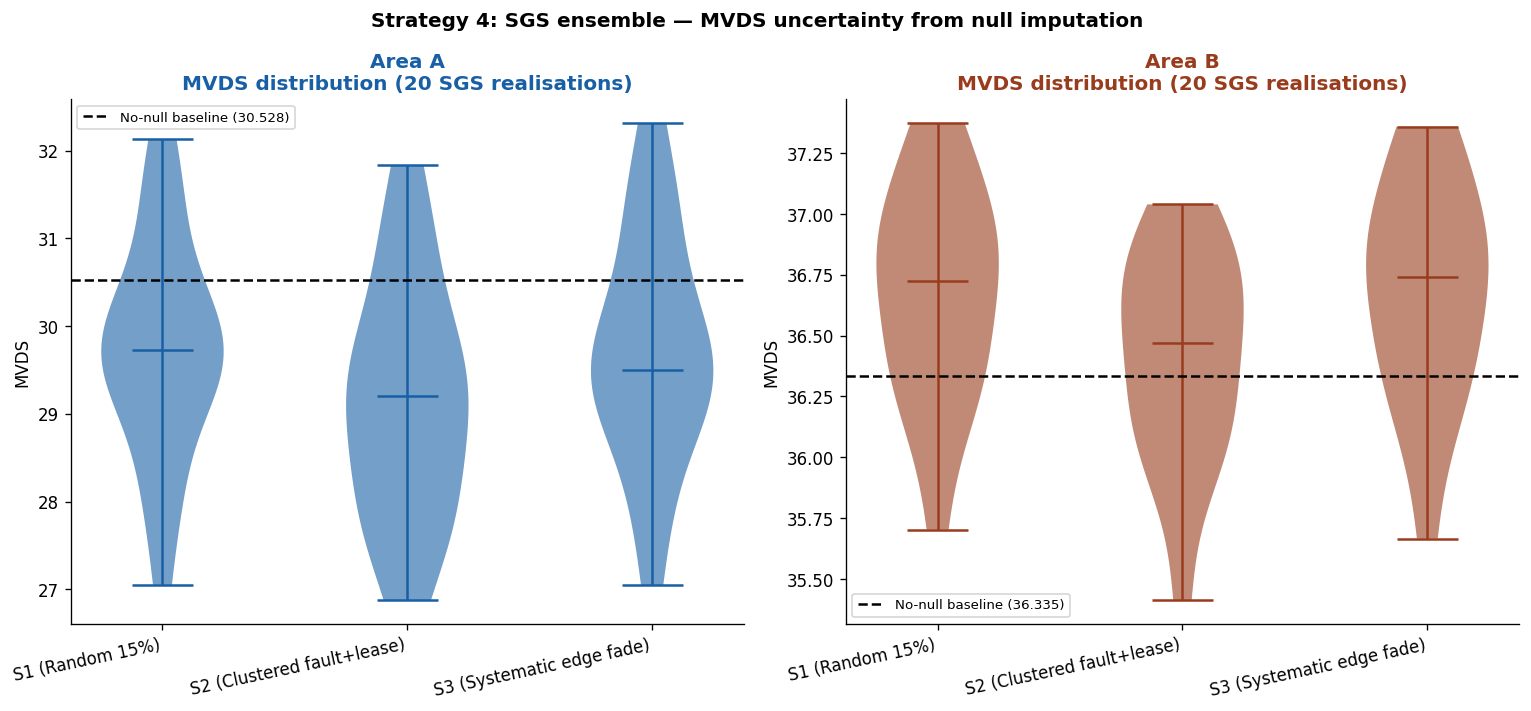

In [13]:
# Violin plots of MVDS distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sc_names = list(null_masks.keys())
for col, area in enumerate(AREAS):
    ax = axes[col]
    data = [s4[area][sc]['all'] for sc in sc_names]
    parts = ax.violinplot(data, positions=range(1,len(sc_names)+1),
                          showmedians=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(COLORS[area]); pc.set_alpha(0.6)
    for key in ['cmedians','cbars','cmins','cmaxes']:
        parts[key].set_color(COLORS[area])
    ax.axhline(baseline_mvds[area], color='black', linestyle='--', lw=1.5,
               label='No-null baseline ' + f'({baseline_mvds[area]:.3f})')
    ax.set_xticks(range(1,len(sc_names)+1))
    ax.set_xticklabels(sc_names, rotation=12, ha='right')
    ax.set_ylabel('MVDS')
    ax.set_title(area + '\nMVDS distribution (' + str(N_REAL) + ' SGS realisations)',
                 fontweight='bold', color=COLORS[area])
    ax.legend(fontsize=8)
plt.suptitle('Strategy 4: SGS ensemble — MVDS uncertainty from null imputation',
             fontweight='bold')
plt.tight_layout()
plt.savefig('s4_violin.png', dpi=130, bbox_inches='tight')
plt.show()

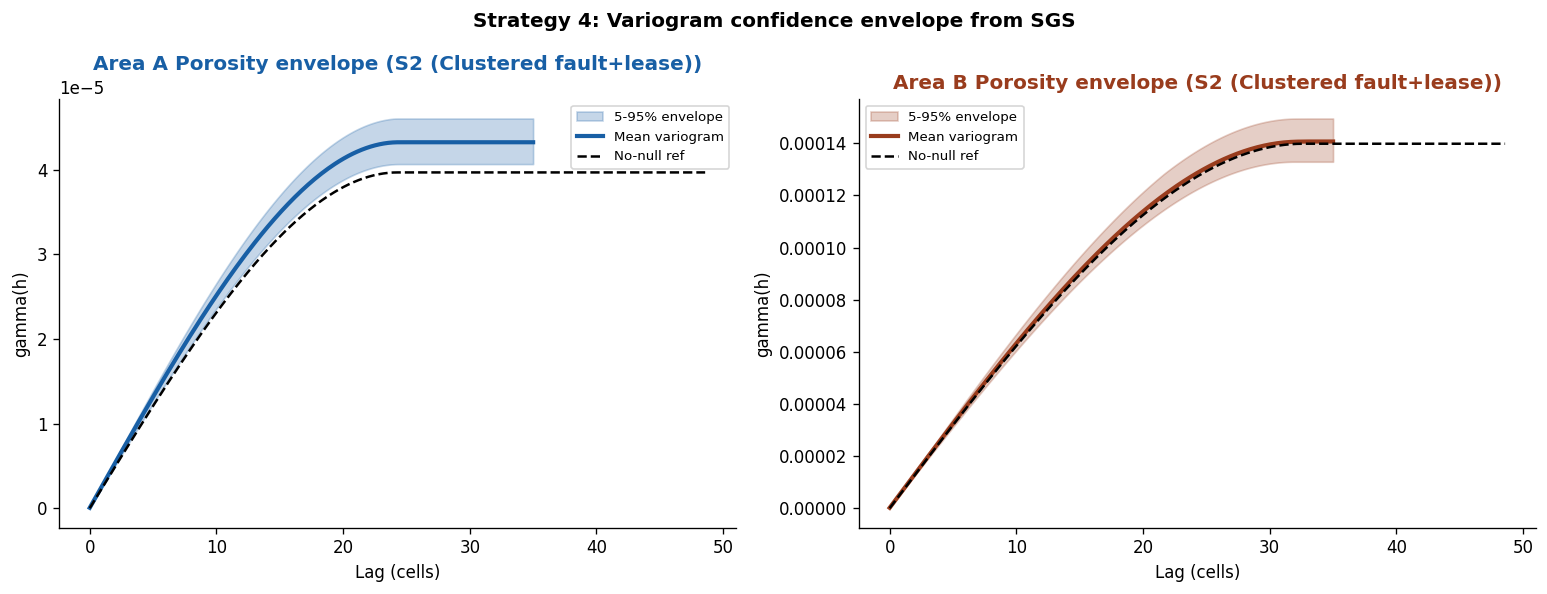

In [14]:
# Variogram confidence envelope — Porosity, S2
sc_focus = 'S2 (Clustered fault+lease)'
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
h_common = np.linspace(0, 35, 200)
for col, area in enumerate(AREAS):
    ax = axes[col]
    curves = []
    for h, g in s4_gammas[area][sc_focus]:
        p, _, _ = fit_variogram(h, g)
        if p is not None:
            curves.append(spherical(h_common, *p))
    if curves:
        curves = np.array(curves)
        ax.fill_between(h_common, np.percentile(curves,5,axis=0),
                        np.percentile(curves,95,axis=0),
                        alpha=0.25, color=COLORS[area], label='5-95% envelope')
        ax.plot(h_common, curves.mean(axis=0), '-', color=COLORS[area],
                lw=2.5, label='Mean variogram')
    # Reference
    flat_ref = grids[area]['Porosity'].ravel()
    h_ref, g_ref = sample_pairs(flat_ref, np.ones(len(flat_ref), dtype=bool))
    p_ref, _, hf = fit_variogram(h_ref, g_ref)
    if p_ref is not None:
        ax.plot(hf, spherical(hf, *p_ref), 'k--', lw=1.5, label='No-null ref')
    ax.set_xlabel('Lag (cells)'); ax.set_ylabel('gamma(h)')
    ax.set_title(area + ' Porosity envelope (' + sc_focus + ')',
                 fontweight='bold', color=COLORS[area])
    ax.legend(fontsize=8)
plt.suptitle('Strategy 4: Variogram confidence envelope from SGS',
             fontweight='bold')
plt.tight_layout()
plt.savefig('s4_envelope.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Strategy 5 — EM variogram fitting

Iterates between:

- **E-step:** Compute expected squared differences at null-containing pairs
  using conditional mean from Simple Kriging given the current variogram model
- **M-step:** Re-fit variogram to the complete observed+expected semivariance cloud

Converges to the maximum-likelihood variogram — no random imputation needed.
Stops when |MVDS change| < 1e-4 between iterations.

In [15]:
def em_variogram(grid, mask, n_lags=18, max_lag_frac=0.45,
                 n_sample=1200, max_iter=8, tol=1e-4, seed=5):
    rng_  = np.random.default_rng(seed)
    rows, cols = grid.shape
    flat  = grid.ravel().copy().astype(float)
    valid_flat = mask.ravel()
    mu_g  = flat[valid_flat].mean()
    sg_g  = flat[valid_flat].std() + 1e-12
    z     = (flat - mu_g) / sg_g
    # Sample valid nodes
    valid_idx = np.where(valid_flat)[0]
    idx  = rng_.choice(valid_idx, size=min(n_sample, len(valid_idx)), replace=False)
    ri, ci = np.unravel_index(idx, (rows, cols))
    coords_v = np.stack([ri, ci], axis=1).astype(float)
    # Sample null nodes
    null_idx  = np.where(~valid_flat)[0]
    n_null_s  = min(250, len(null_idx))
    null_samp = rng_.choice(null_idx, n_null_s, replace=False)
    ri_n, ci_n = np.unravel_index(null_samp, (rows, cols))
    coords_n  = np.stack([ri_n, ci_n], axis=1).astype(float)
    # All sampled nodes
    coords_all = np.vstack([coords_v, coords_n])
    is_valid   = np.array([True]*len(idx) + [False]*n_null_s)
    z_obs      = np.concatenate([z[idx], np.zeros(n_null_s)])
    D_all = squareform(pdist(coords_all))
    max_d = squareform(pdist(coords_v)).max() * max_lag_frac
    lags  = np.linspace(0, max_d, n_lags+1)
    centers = (lags[:-1]+lags[1:])/2
    # Initial fit from valid-only pairs
    D_vv = squareform(pdist(coords_v))
    g_init = []
    for lo, hi in zip(lags[:-1], lags[1:]):
        mk = (D_vv>lo)&(D_vv<=hi)
        if mk.sum()<5: g_init.append(np.nan); continue
        ii,jj = np.where(mk)
        g_init.append(0.5*np.mean((z[idx[ii]]-z[idx[jj]])**2))
    popt, _, _ = fit_variogram(centers, np.array(g_init))
    if popt is None: popt = [0.05, 1.0, max_d*0.5]
    prev_integ = np.inf
    for iteration in range(max_iter):
        nugget, sill, rang = popt
        C_all = np.where(D_all<=rang,
                         sill*(1-1.5*(D_all/rang)+0.5*(D_all/rang)**3), 0.0)
        np.fill_diagonal(C_all, sill+nugget)
        vv_mask = is_valid
        C_vv = C_all[np.ix_(vv_mask, vv_mask)]
        C_nv = C_all[np.ix_(~vv_mask, vv_mask)]
        z_v  = z_obs[vv_mask]
        try:
            C_vv_inv = np.linalg.solve(C_vv+1e-6*np.eye(C_vv.shape[0]),
                                        np.eye(C_vv.shape[0]))
            z_obs[~vv_mask] = C_nv @ C_vv_inv @ z_v
        except Exception:
            pass
        g_em = []
        for lo, hi in zip(lags[:-1], lags[1:]):
            mk = (D_all>lo)&(D_all<=hi)
            if mk.sum()<5: g_em.append(np.nan); continue
            ii,jj = np.where(mk)
            g_em.append(0.5*np.mean((z_obs[ii]-z_obs[jj])**2))
        g_em = np.array(g_em)
        new_popt, integral, _ = fit_variogram(centers, g_em, p0=popt)
        if new_popt is None: break
        popt = new_popt
        if abs(integral-prev_integ)/(abs(prev_integ)+1e-8) < tol: break
        prev_integ = integral
    return centers, g_em, popt, iteration+1

s5 = {}
for area in AREAS:
    s5[area] = {}
    for sc_name, mask in null_masks.items():
        integrals = {}
        for prop in PROPS:
            h, g, _, n_iter = em_variogram(grids[area][prop], mask, max_iter=8)
            _, integral, _ = fit_variogram(h, g)
            integrals[prop] = integral
        s5[area][sc_name] = mvds_from_integrals(integrals)
        print(f'S5 | {area} | {sc_name}: MVDS={s5[area][sc_name]:.4f}')

S5 | Area A | S1 (Random 15%): MVDS=26.0577
S5 | Area A | S2 (Clustered fault+lease): MVDS=25.4828
S5 | Area A | S3 (Systematic edge fade): MVDS=25.3503
S5 | Area B | S1 (Random 15%): MVDS=37.3066
S5 | Area B | S2 (Clustered fault+lease): MVDS=34.4648
S5 | Area B | S3 (Systematic edge fade): MVDS=35.6737


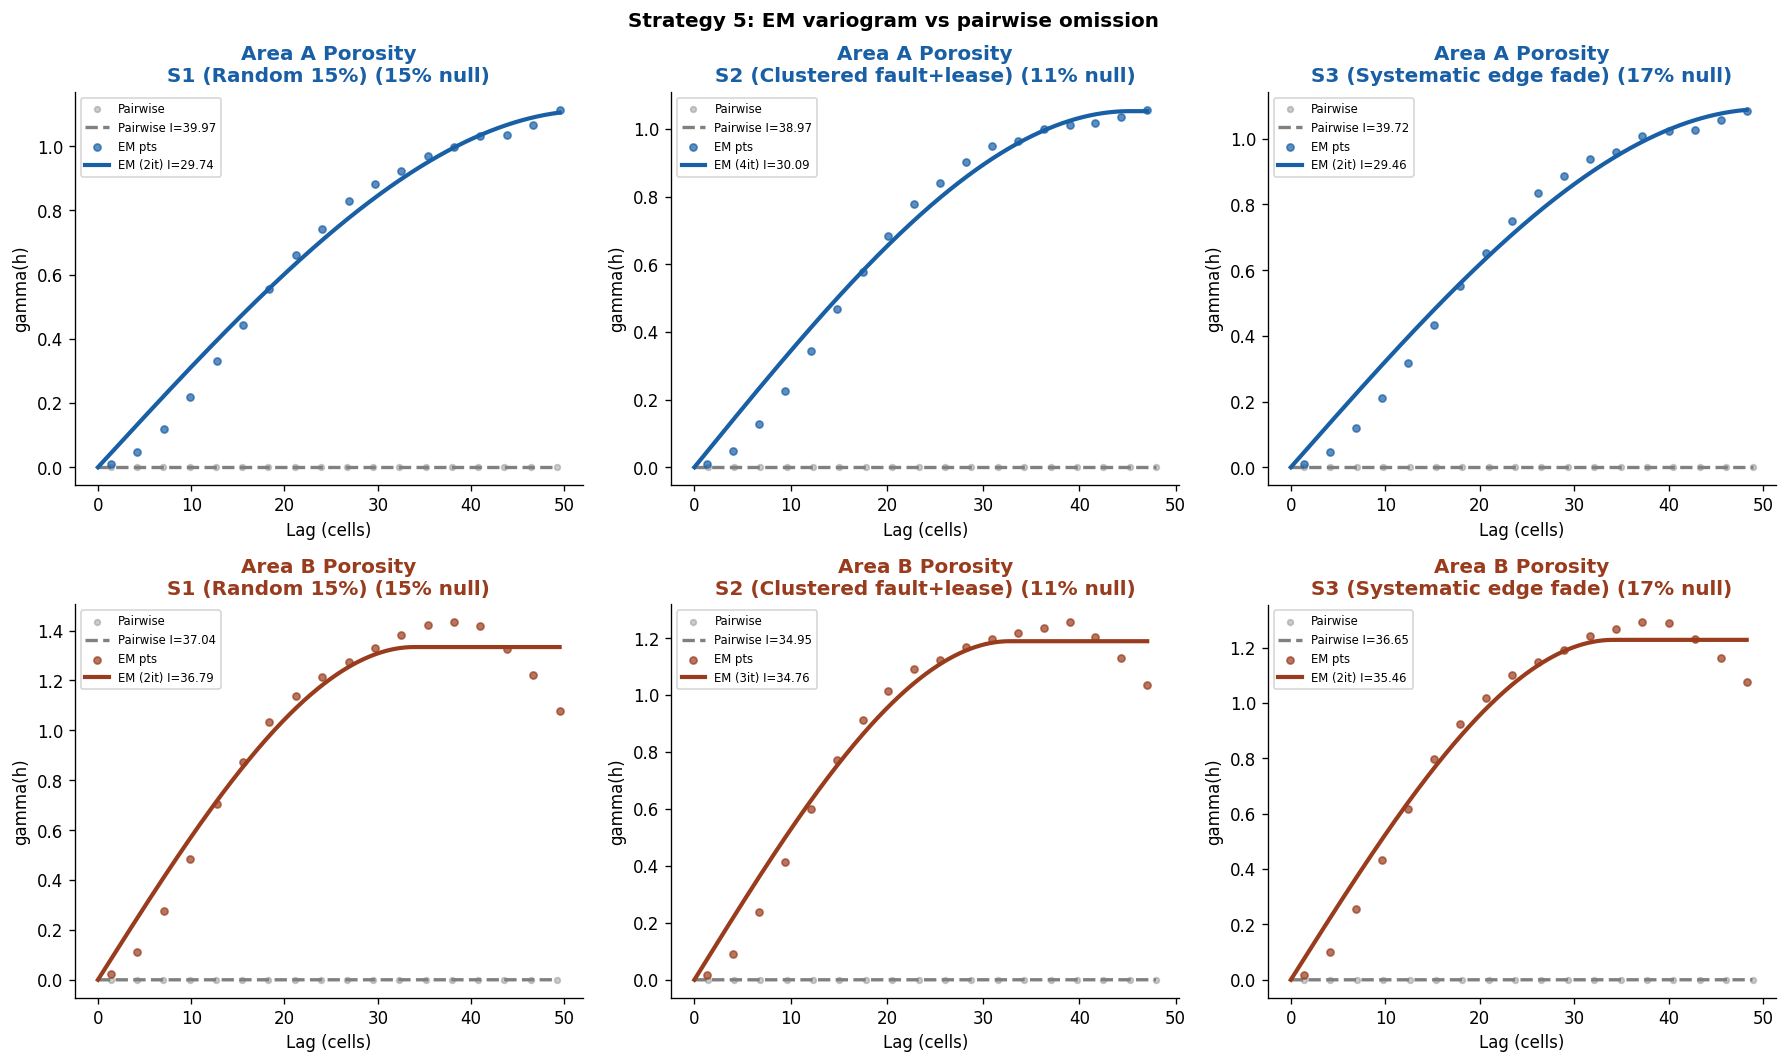

In [16]:
# EM vs pairwise — Porosity variogram comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, area in enumerate(AREAS):
    for col, (sc_name, mask) in enumerate(null_masks.items()):
        ax = axes[row, col]
        flat = grids[area]['Porosity'].ravel()
        # Pairwise
        h1, g1 = sample_pairs(flat, mask.ravel(), n_sample=1500)
        if h1 is not None:
            v = ~np.isnan(g1)
            ax.scatter(h1[v], g1[v], s=12, color='gray', alpha=0.4, label='Pairwise')
            p1, i1, hf = fit_variogram(h1, g1)
            if p1 is not None:
                ax.plot(hf, spherical(hf, *p1), '--', color='gray', lw=2,
                        label='Pairwise I=' + f'{i1:.2f}')
        # EM
        h5, g5, p5, n5 = em_variogram(grids[area]['Porosity'], mask, max_iter=8)
        if h5 is not None:
            v5 = ~np.isnan(g5)
            ax.scatter(h5[v5], g5[v5], s=18, color=COLORS[area],
                       alpha=0.7, zorder=3, label='EM pts')
            p5f, i5, hf5 = fit_variogram(h5, g5)
            if p5f is not None:
                ax.plot(hf5, spherical(hf5, *p5f), '-', color=COLORS[area], lw=2.5,
                        label=f'EM ({n5}it) I={i5:.2f}')
        pct = (1-mask.mean())*100
        ax.set_title(area + ' Porosity\n' + sc_name + f' ({pct:.0f}% null)',
                     fontweight='bold', color=COLORS[area])
        ax.set_xlabel('Lag (cells)'); ax.set_ylabel('gamma(h)')
        ax.legend(fontsize=7)
plt.suptitle('Strategy 5: EM variogram vs pairwise omission', fontweight='bold')
plt.tight_layout()
plt.savefig('s5_em.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Master comparison — all strategies, all scenarios, both areas

Shows % deviation of each strategy's MVDS from the no-null baseline.

- **Blue** = underestimates heterogeneity vs baseline
- **Red** = overestimates heterogeneity vs baseline
- Near **zero** = robust to the null pattern

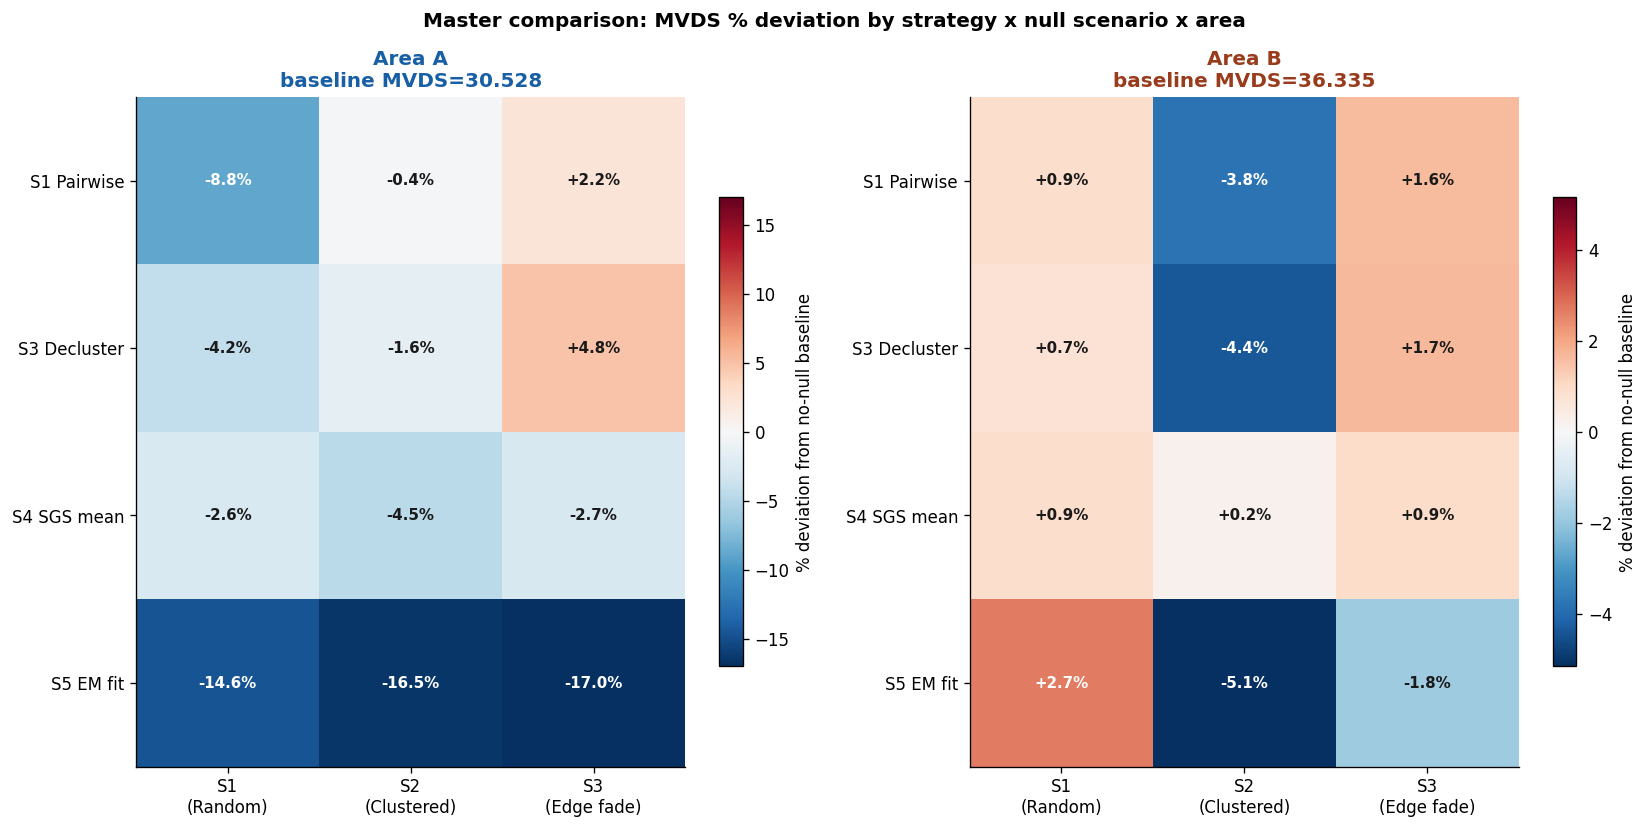

In [17]:
strategies = [
    ('S1 Pairwise', s1),
    ('S3 Decluster', s3),
    ('S4 SGS mean', {a: {sc: s4[a][sc]['mean'] for sc in null_masks} for a in AREAS}),
    ('S5 EM fit',  s5),
]
sc_list = list(null_masks.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for col, area in enumerate(AREAS):
    ax = axes[col]
    base = baseline_mvds[area]
    mat  = np.zeros((len(strategies), len(sc_list)))
    for i, (s_name, s_dict) in enumerate(strategies):
        for j, sc in enumerate(sc_list):
            val = s_dict[area][sc]
            mat[i,j] = (val - base)/(base+1e-12)*100
    vmax = max(np.abs(mat).max(), 3)
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.7, label='% deviation from no-null baseline')
    ax.set_xticks(range(len(sc_list)))
    ax.set_xticklabels(['S1\n(Random)', 'S2\n(Clustered)', 'S3\n(Edge fade)'])
    ax.set_yticks(range(len(strategies)))
    ax.set_yticklabels([s[0] for s in strategies])
    for i in range(len(strategies)):
        for j in range(len(sc_list)):
            ax.text(j, i, f'{mat[i,j]:+.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if abs(mat[i,j])>vmax*0.5 else '#1a1a1a')
    ax.set_title(area + '\nbaseline MVDS=' + f'{base:.3f}',
                 fontweight='bold', color=COLORS[area])
plt.suptitle('Master comparison: MVDS % deviation by strategy x null scenario x area',
             fontweight='bold')
plt.tight_layout()
plt.savefig('master_mvds_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

In [18]:
# Full summary table
rows_out = []
for s_name, s_dict in strategies:
    for sc in sc_list:
        row = {'Strategy': s_name, 'Scenario': sc}
        for area in AREAS:
            val = s_dict[area][sc]
            base = baseline_mvds[area]
            row[area + ' MVDS'] = round(val, 4)
            row[area + ' %dev'] = round((val-base)/(base+1e-12)*100, 1)
        rows_out.append(row)
comp_df = pd.DataFrame(rows_out).set_index(['Strategy','Scenario'])
print('='*70)
print('FULL MVDS COMPARISON TABLE')
print('='*70)
print(comp_df.to_string())
print()
print('Baseline MVDS (no nulls):')
for area in AREAS:
    print(f'  {area}: {baseline_mvds[area]:.4f}')

FULL MVDS COMPARISON TABLE
                                         Area A MVDS  Area A %dev  Area B MVDS  Area B %dev
Strategy     Scenario                                                                      
S1 Pairwise  S1 (Random 15%)                 27.8370         -8.8      36.6645          0.9
             S2 (Clustered fault+lease)      30.4184         -0.4      34.9485         -3.8
             S3 (Systematic edge fade)       31.1907          2.2      36.9285          1.6
S3 Decluster S1 (Random 15%)                 29.2566         -4.2      36.5986          0.7
             S2 (Clustered fault+lease)      30.0359         -1.6      34.7535         -4.4
             S3 (Systematic edge fade)       31.9982          4.8      36.9421          1.7
S4 SGS mean  S1 (Random 15%)                 29.7318         -2.6      36.6703          0.9
             S2 (Clustered fault+lease)      29.1465         -4.5      36.4192          0.2
             S3 (Systematic edge fade)       29.7187 

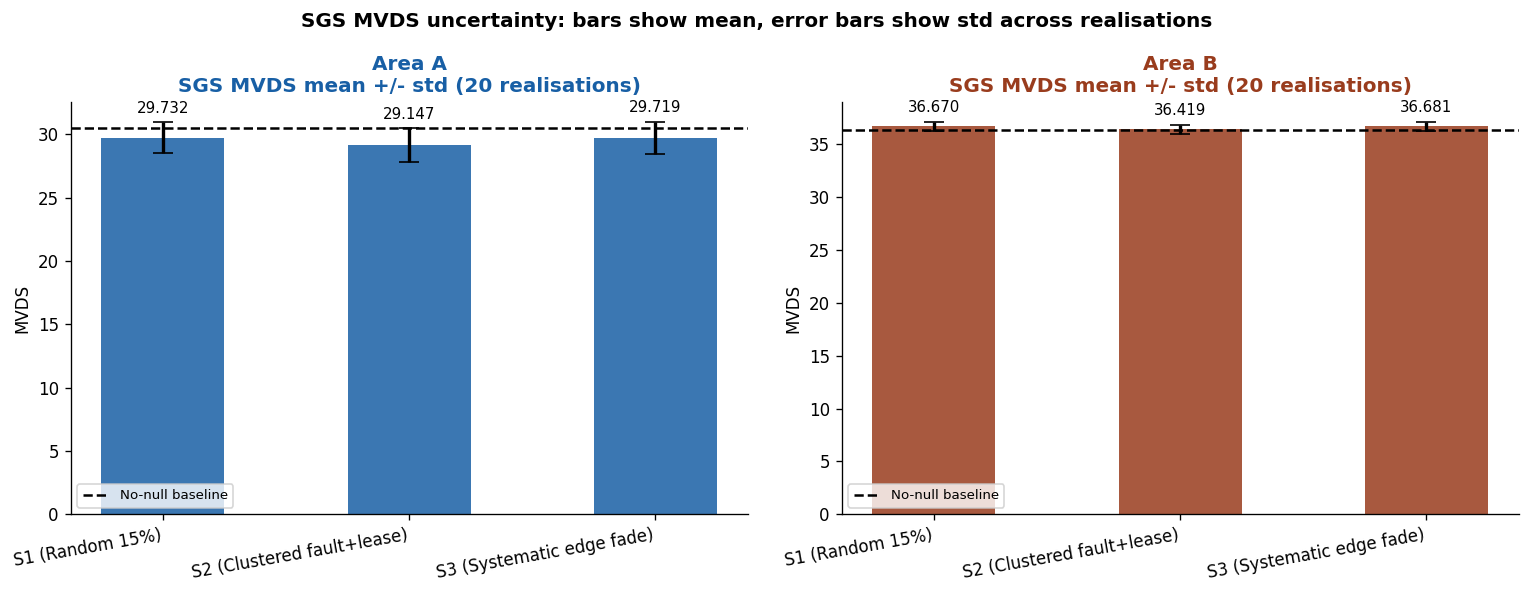

In [19]:
# MVDS mean +/- std from SGS per area and scenario
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_pos = np.arange(len(sc_list))
for col, area in enumerate(AREAS):
    ax = axes[col]
    means = [s4[area][sc]['mean'] for sc in sc_list]
    stds  = [s4[area][sc]['std']  for sc in sc_list]
    bars = ax.bar(x_pos, means, yerr=stds, capsize=6,
                  color=COLORS[area], alpha=0.85, width=0.5,
                  error_kw={'elinewidth': 2, 'ecolor': 'black'})
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.axhline(baseline_mvds[area], color='black', linestyle='--', lw=1.5,
               label='No-null baseline')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sc_list, rotation=10, ha='right')
    ax.set_ylabel('MVDS')
    ax.set_title(area + '\nSGS MVDS mean +/- std (' + str(N_REAL) + ' realisations)',
                 fontweight='bold', color=COLORS[area])
    ax.legend(fontsize=8)
plt.suptitle('SGS MVDS uncertainty: bars show mean, error bars show std across realisations',
             fontweight='bold')
plt.tight_layout()
plt.savefig('s4_mvds_uncertainty.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Strategy selection guide

| Step | Check | Action |
|------|-------|--------|
| 1 | Run Strategy 2 (indicator variogram) | Compute Nugget/Sill ratio |
| 2 | Nugget/Sill **> 0.6** | Use Strategy 1 (pairwise omission) — fast & unbiased |
| 3 | Nugget/Sill **0.3–0.6** | Use Strategy 3 + 5, compare results |
| 4 | Nugget/Sill **< 0.3** | Use Strategy 4 (SGS) for uncertainty + Strategy 5 for best estimate |
| 5 | Null fraction **> 30%** | SGS ensemble is mandatory — report MVDS ± std |
| 6 | A vs B ranking **flips** across strategies | Null pattern too severe to rank — collect more data |

| Strategy | Accounts for null location? | Handles clustering? | Gives uncertainty? |
|----------|---------------------------|--------------------|--------------------|---|
| 1. Pairwise omission | No | No | No |
| 2. Indicator diagnostic | Yes (flags it) | Yes | No |
| 3. Declustering | Yes | Yes | No |
| 4. SGS ensemble | Yes | Yes | **Yes** |
| 5. EM fitting | Yes | Partial | No |

**Recommended workflow:**
Strategy 2 (diagnose) → Strategy 5 (best estimate) + Strategy 4 (uncertainty) → Report MVDS ± std